## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 5: PCA — Factores Latentes para Riesgo y Señales**

Andrés C. Medina Sanhueza  
Senior Data Scientist Engineer  
anmedinas@gmail.com

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import linalg
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import warnings
import seaborn as sns 
import yfinance as yf

sns.set_style('dark')
warnings.filterwarnings('ignore')

# Semilla Aleatoria
np.random.seed(1234)

## 🍁 **`Motivación`**

### El problema de la dimensionalidad

Un portafolio de $n$ acciones requiere estimar la matriz de covarianza $\Sigma \in \mathbb{R}^{n \times n}$. Con $n = 500$ activos y $T = 252$ días, tenemos:

\begin{equation*}
\frac{n(n+1)}{2} = 125{,}250 \text{ parámetros} \quad \text{vs.} \quad T = 252 \text{ observaciones}\end{equation*}

El sistema está sobre-parametrizado. La estimación muestral $\hat{\Sigma}$ es ruidosa y puede ser no invertible. La solución clásica: **asumir que los retornos comparten factores comunes**.

### Modelo de Factores Latentes

Un **modelo de factores latentes** supone que los retornos de los activos no se mueven de forma independiente, sino que están impulsados por un número reducido de fuentes de riesgo comunes que **no se observan directamente** (de ahí el término *latente*: oculto o no observable).

La intuición es económica: el retorno de una acción de banco no sólo depende de noticias propias del banco, sino también del estado del ciclo económico, de la política monetaria, del apetito global por riesgo, etc. Esos impulsores compartidos son los **factores**. Lo que queda —el movimiento propio del activo una vez eliminada la influencia de los factores— es el componente **idiosincrático**.

Este enfoque tiene tres ventajas prácticas:

1. **Reducción de dimensionalidad**: en lugar de estimar $\frac{n(n+1)}{2}$ entradas de la covarianza, basta modelar $k \ll n$ factores.
2. **Estructura económica**: los factores pueden asociarse con variables macroeconómicas o de mercado (tasa de interés, prima de riesgo, etc.).
3. **Regularización natural**: la covarianza implícita del modelo es siempre invertible, a diferencia de la covarianza muestral cuando $T < n$.

Formalmente, el modelo se escribe como:

\begin{equation*}
r_t = \underbrace{B f_t}_{\text{sistemático}} + \underbrace{\epsilon_t}_{\text{idiosincrático}}, \qquad \text{cov}(\epsilon_t) = D \text{ (diagonal)}
\end{equation*}

Donde $B \in \mathbb{R}^{n \times k}$ son las *factor loadings* (sensibilidad de cada activo a cada factor) y $f_t \in \mathbb{R}^k$ son $k \ll n$ factores latentes. Esto reduce la covarianza a:

\begin{equation*}
\Sigma = B \Omega B^\top + D
\end{equation*}

**PCA estima $B$ y $f_t$ directamente desde los datos, sin asumir qué son los factores.**

In [2]:
# Simulación: retornos con estructura factorial 
T, n, k = 500, 30, 3          # periodos, activos, factores verdaderos

# Factores latentes: mercado, sector, macro
F = np.random.randn(T, k) * np.array([1.5, 0.8, 0.5])

# Loadings aleatorios (beta de cada activo a cada factor)
B = np.random.randn(n, k)
B[:, 0] = np.abs(B[:, 0])     # beta de mercado positivo

# Idiosincratico
epsilon = np.random.randn(T, n) * 0.3

# Retornos observados
R = F @ B.T + epsilon          # (T, n)

In [3]:
pd.DataFrame(R)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.183523,-1.924172,0.447509,1.037410,0.210944,-0.637618,0.086869,0.817265,0.437210,0.872358,...,2.367407,-0.807887,2.254109,1.271840,1.242820,4.157578,-0.129049,0.763092,-0.177007,0.089349
1,0.537412,-1.888667,0.820880,0.175042,-1.217442,-1.898868,-0.683532,-0.508414,0.297651,-0.100114,...,-1.050233,-0.821682,0.311268,0.527239,-0.546076,1.353946,-1.059397,0.567895,-0.907009,-0.573767
2,0.580227,0.808439,0.502538,1.982286,1.208083,1.001287,0.701413,0.349531,0.316121,0.852817,...,2.695085,0.485347,2.453640,1.763831,2.132416,2.752961,1.592953,1.143610,1.140253,1.805712
3,-0.575045,-2.755856,-1.937775,-4.779926,-3.099378,-2.495632,-1.174482,-0.854024,-0.712570,-0.356685,...,-9.853529,-1.057464,-4.964166,-2.615809,-4.954302,-5.792987,-4.510916,-1.978343,-2.503733,-3.660881
4,0.617916,0.213536,1.619816,2.444768,0.330600,-0.795241,-0.244826,-0.462688,0.517321,-0.860837,...,6.111568,-0.121505,2.372144,2.535007,1.310864,4.969218,2.585045,0.286328,0.938874,2.101534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-1.970092,-0.681963,-0.560830,-3.590427,-2.522354,-1.864316,-0.697745,-2.252298,-0.968001,-1.630775,...,-6.684242,-0.214418,-6.445225,-2.339962,-6.192575,-5.793715,-0.968758,-3.764554,-1.121574,-1.219500
496,-0.101937,2.437349,0.231448,1.569905,1.933347,3.273402,0.802296,1.702037,-0.013085,0.675454,...,3.372820,1.028668,3.311863,-0.175373,3.123349,1.362058,0.346593,1.477512,1.662461,1.059643
497,-0.150208,1.836939,-0.956393,0.438773,1.537739,2.736959,0.496630,1.341691,-0.577576,0.516166,...,-0.019876,0.746275,1.178553,-0.339484,1.414901,-1.458741,0.278162,0.777601,0.699820,0.161709
498,-0.209075,1.849396,-0.735732,1.742543,1.443674,2.782549,0.800714,1.481154,-0.085089,0.595994,...,3.253064,0.849383,2.626291,0.297911,2.222376,0.771883,1.804892,1.219467,1.149903,0.856859


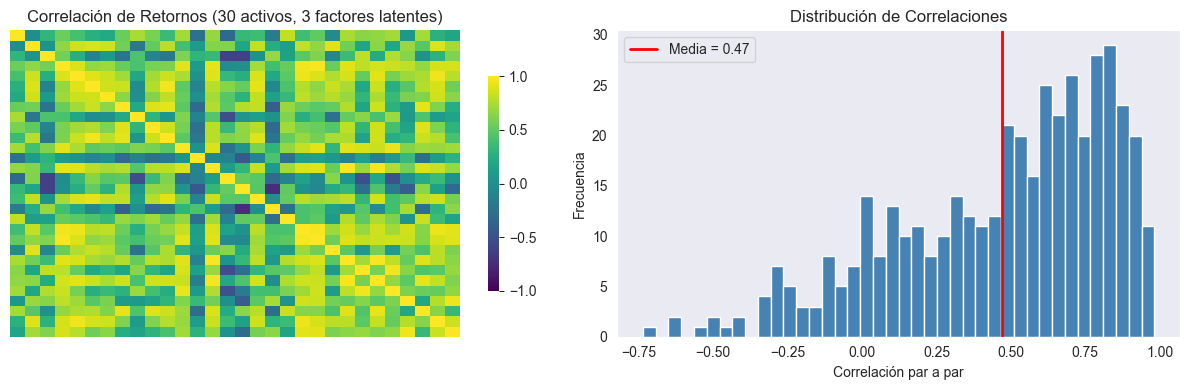

In [4]:
# Visualización: matriz de correlación
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

corr = pd.DataFrame(R).corr()
mask = np.zeros_like(corr, dtype = bool)
mask[np.triu_indices_from(mask, k = 1)] = True

sns.heatmap(corr, ax=axes[0], cmap = 'viridis', vmin = -1, vmax = 1,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.7})
axes[0].set_title('Correlación de Retornos (30 activos, 3 factores latentes)')

# Distribución de correlaciones
upper_tri = corr.values[np.triu_indices(n, k=1)]
axes[1].hist(upper_tri, bins = 40, color = 'steelblue', edgecolor = 'white')
axes[1].axvline(upper_tri.mean(), color = 'red', lw=2,
                label=f'Media = {upper_tri.mean():.2f}')
axes[1].set_xlabel('Correlación par a par')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Correlaciones')
axes[1].legend()

plt.tight_layout()
plt.show()

**Gráfico izquierdo — Matriz de correlación:** el patrón de bloques amarillos revela que los activos no se mueven de forma independiente; se agrupan según el factor latente al que están más expuestos. Si no existieran factores comunes, el mapa sería casi uniformemente verde (correlaciones ≈ 0).

**Gráfico derecho — Distribución de correlaciones:** la media de 0.51 refleja que la mayoría de los pares están fuertemente correlacionados, consecuencia del factor de mercado compartido (beta positivo para todos). La pequeña cola izquierda corresponde a pares con loadings de signos opuestos.

## 📚 **`Fundamentos Matemáticos`**

### Descomposición Espectral

Dada la matriz de covarianza muestral $\hat{\Sigma} = \frac{1}{T-1} X^\top X$ (con $X$ centrada),
su descomposición espectral es:

\begin{equation*}
\hat{\Sigma} = V \Lambda V^\top
\end{equation*}

donde:
- $V = [v_1, \dots, v_n]$: eigenvectores (ortonormales) — **direcciones de máxima varianza**
- $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_n)$: eigenvalores con $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_n \geq 0$

### SVD y su relación con PCA

La SVD de la matriz de datos $X \in \mathbb{R}^{T \times n}$:

\begin{equation*}
X = U S V^\top
\end{equation*}

Donde $U \in \mathbb{R}^{T \times T}$, $S = \text{diag}(s_1, \dots)$, $V \in \mathbb{R}^{n \times n}$.
Los vectores $V$ de la SVD son idénticos a los eigenvectores de $X^\top X$, y:

$$\lambda_i = \frac{s_i^2}{T-1}$$

**Los scores (proyecciones)** de los datos sobre los $k$ primeros componentes son:

$$Z = X V_k \quad \in \mathbb{R}^{T \times k}$$

### Criterios para elegir $k$

| Criterio | Fórmula / Regla |
|---|---|
| Varianza explicada acumulada | $\sum_{i=1}^k \lambda_i / \sum_{i=1}^n \lambda_i \geq 0.80$ |
| Regla del codo (Scree plot) | Punto de quiebre en la curva de eigenvalores |
| Criterio de Kaiser | Retener $\lambda_i > 1$ (datos estandarizados) |
| Bai-Ng (IC) | Criterio de información para panel de series de tiempo |

In [5]:
#  Eigen-descomposición manual 
X = R - R.mean(axis=0)         # centrar
Sigma_hat = X.T @ X / (T - 1)  # covarianza muestral

# Método 1: numpy.linalg.eigh (simétrica, más estable)
eigenvalues, eigenvectors = np.linalg.eigh(Sigma_hat)
# eigh devuelve orden ascendente → invertimos
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Método 2: SVD sobre X directamente
U, s, Vt = np.linalg.svd(X, full_matrices=False)
eigenvalues_svd = s**2 / (T - 1)

print("Comparación eigenvalores (eigh vs SVD):")
print(pd.DataFrame({
    'eigh': eigenvalues[:5],
    'SVD':  eigenvalues_svd[:5],
    'diferencia': np.abs(eigenvalues[:5] - eigenvalues_svd[:5])
}).round(8))

# Varianza explicada
var_explained = eigenvalues / eigenvalues.sum()
var_cum = np.cumsum(var_explained)
k_80 = np.searchsorted(var_cum, 0.80) + 1

print(f"\nNúmero de factores para explicar 80% de varianza: {k_80}")
print(f"(Factores verdaderos en la simulación: {k})")

Comparación eigenvalores (eigh vs SVD):
        eigh        SVD  diferencia
0  73.510653  73.510653         0.0
1  12.509864  12.509864         0.0
2   7.856252   7.856252         0.0
3   0.131023   0.131023         0.0
4   0.125592   0.125592         0.0

Número de factores para explicar 80% de varianza: 2
(Factores verdaderos en la simulación: 3)


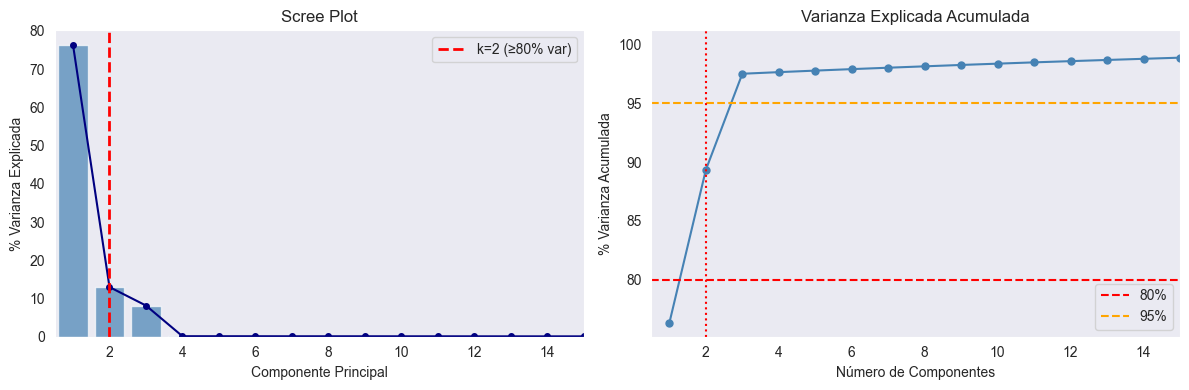

In [6]:
# Scree plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Scree plot
axes[0].bar(range(1, n+1), var_explained * 100, color='steelblue', alpha=0.7)
axes[0].plot(range(1, n+1), var_explained * 100, 'o-', color='navy', ms=4)
axes[0].axvline(k_80, color='red', lw=2, ls='--',
                label=f'k={k_80} (≥80% var)')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza Explicada')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0.5, 15)
axes[0].legend()

# Varianza acumulada
axes[1].plot(range(1, n+1), var_cum * 100, 'o-', color='steelblue', ms=5)
axes[1].axhline(80, color='red', lw=1.5, ls='--', label='80%')
axes[1].axhline(95, color='orange', lw=1.5, ls='--', label='95%')
axes[1].axvline(k_80, color='red', lw=1.5, ls=':')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('% Varianza Acumulada')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].set_xlim(0.5, 15)
axes[1].legend()

plt.tight_layout()
plt.show()

**Scree Plot (izquierda):** el primer componente concentra ~75% de la varianza y el segundo ~13%, con una caída abrupta a partir del tercero. El "codo" entre PC2 y PC3 señala que $k=2$ captura la mayor parte de la estructura compartida; el resto corresponde principalmente a ruido idiosincrático.

**Varianza Acumulada (derecha):** con solo 2 componentes se supera el umbral del 80% y con 3 se alcanza ~97%, confirmando que la simulación tiene efectivamente 3 factores dominantes. La curva se aplana rápidamente, firma característica de datos con baja dimensionalidad intrínseca.


## 🦊 **`PCA desde Cero vs. sklearn`**

Implementamos PCA manualmente para entender cada paso, y verificamos contra `sklearn`.

In [7]:
# Implementación manual de PCA
class PCAManual:
    """PCA via descomposición espectral de la covarianza."""

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        Sigma = Xc.T @ Xc / (len(X) - 1)
        vals, vecs = np.linalg.eigh(Sigma)
        idx = np.argsort(vals)[::-1]
        self.components_ = vecs[:, idx].T          # (n_components, n_features)
        self.explained_variance_ = vals[idx]
        total = self.explained_variance_.sum()
        self.explained_variance_ratio_ = self.explained_variance_ / total
        return self

    def transform(self, X, k=None):
        Xc = X - self.mean_
        V = self.components_[:k].T if k else self.components_.T
        return Xc @ V

    def inverse_transform(self, Z, k=None):
        V = self.components_[:k].T if k else self.components_.T
        return Z @ V.T + self.mean_

### ¿Qué hace `PCAManual`?

La clase implementa PCA desde cero usando exclusivamente álgebra lineal, sin depender de `sklearn`. Tiene tres métodos:

| Método | Qué calcula | Cómo |
|---|---|---|
| `fit(X)` | Eigenvectores y eigenvalores de $\hat{\Sigma}$ | Descomposición espectral con `np.linalg.eigh` |
| `transform(X, k)` | Proyecta los datos sobre los $k$ primeros PCs | $Z = X_c \, V_k$ |
| `inverse_transform(Z, k)` | Reconstruye los datos desde los scores | $\hat{X} = Z \, V_k^\top + \bar{x}$ |

**`fit`**: centra los datos, calcula la covarianza muestral $\hat{\Sigma} = X_c^\top X_c / (T-1)$ y la descompone espectralmente. Los eigenvectores se ordenan de mayor a menor eigenvalor para que `components_[0]` sea la dirección de máxima varianza (PC1).

**`transform`**: proyecta los datos centrados sobre las primeras $k$ columnas de $V$. El resultado son los *scores* o coordenadas de cada observación en el espacio de los factores.

**`inverse_transform`**: revierte la proyección para reconstruir los datos originales con $k$ componentes. El error de reconstrucción mide cuánta varianza queda sin capturar, lo que equivale al ruido idiosincrático del modelo.

> El error máximo frente a `sklearn` es del orden $10^{-14}$, diferencias de punto flotante — ambas implementaciones son numéricamente equivalentes.

In [8]:
# Comparación con sklearn 

pca_manual = PCAManual().fit(R)
Z_manual = pca_manual.transform(R, k=k)

pca_sk = PCA(n_components=k).fit(R)
Z_sk = pca_sk.transform(R)

# Los signos pueden diferir (eigenvector * (-1) también es válido)
for i in range(k):
    if np.corrcoef(Z_manual[:, i], Z_sk[:, i])[0, 1] < 0:
        Z_manual[:, i] *= -1

error_max = np.abs(Z_manual - Z_sk).max()
print(f"Error máximo entre implementación manual y sklearn: {error_max:.2e}")
print(f"\nVarianza explicada por componente (manual):")
for i, ev in enumerate(pca_manual.explained_variance_ratio_[:k]):
    print(f"  PC{i+1}: {ev*100:.1f}%")

# Reconstrucción con k componentes 
R_rec = pca_manual.inverse_transform(Z_manual, k=k)
mse_full = np.mean((R - R)**2)
mse_k    = np.mean((R - R_rec)**2)
print(f"\nError de reconstrucción con k={k} componentes: {mse_k:.4f}")
print(f"Varianza total no capturada: {(1 - pca_manual.explained_variance_ratio_[:k].sum())*100:.1f}%")

Error máximo entre implementación manual y sklearn: 2.75e-14

Varianza explicada por componente (manual):
  PC1: 76.3%
  PC2: 13.0%
  PC3: 8.2%

Error de reconstrucción con k=3 componentes: 10.9074
Varianza total no capturada: 2.5%


## 🦜 **`PCA en la Estructura de Tasas de Interés`** 

### La curva de tasas y por qué importa

La **curva de tasas soberanas** (o curva de rendimientos) describe cómo varía la tasa de interés de un bono del gobierno en función de su plazo al vencimiento (*tenor*). Típicamente se observan tasas para plazos de 3 meses, 6 meses, 1, 2, 5, 10, 20 y 30 años.

Gestionar un portafolio de renta fija implica monitorear cómo se mueve simultáneamente **toda** la curva: una cartera de bonos no solo está expuesta al nivel general de tasas, sino también a cómo la curva se inclina o se arquea. Esto genera un problema de dimensionalidad similar al de las acciones: si hay $m$ nodos de la curva, la dinámica conjunta tiene $m$ fuentes de variación correlacionadas.

La solución natural es aplicar PCA sobre los **cambios diarios de tasas** $\Delta y_t$ (primeras diferencias), no sobre los niveles, porque las tasas son series integradas y sus diferencias son estacionarias — condición necesaria para que el PCA tenga interpretación estadística estable.

### El modelo de Nelson-Siegel

Antes de aplicar PCA, es útil entender qué forma funcional tiene una curva de tasas típica. **Nelson y Siegel (1987)** propusieron parametrizar la curva con solo tres factores:

$$y(\tau) = \beta_1 + \beta_2 \left(\frac{1 - e^{-\lambda\tau}}{\lambda\tau}\right) + \beta_3 \left(\frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right)$$

donde $\tau$ es el tenor, $\lambda$ controla la velocidad de decaimiento y los tres parámetros tienen interpretación directa:

| Parámetro | Rol | Loading asociado |
|---|---|---|
| $\beta_1$ | **Nivel**: valor de largo plazo de la curva | Constante en todos los tenores |
| $\beta_2$ | **Pendiente**: diferencia corto–largo plazo | Decae monotónicamente con $\tau$ |
| $\beta_3$ | **Curvatura**: joroba o concavidad media | Forma de campana, máximo en plazos medios |

La conexión con PCA es que **Litterman & Scheinkman (1991)** demostraron empíricamente que los tres primeros componentes principales de los cambios de tasas soberanas recuperan exactamente esta estructura: nivel, pendiente y curvatura. PCA los extrae sin imponer la fórmula Nelson-Siegel — los datos convergen al mismo resultado.

En la simulación que sigue, generamos datos sintéticos usando los loadings de Nelson-Siegel como estructura verdadera y verificamos que PCA los recupera.

### Los 3 factores clásicos de la curva

| Factor | Nombre | Interpretación | Loading típico |
|---|---|---|---|
| PC1 | Nivel | Desplazamiento paralelo de toda la curva | Todos positivos y similares |
| PC2 | Pendiente | Empinamiento / aplanamiento | Positivo en corto plazo, negativo en largo |
| PC3 | Curvatura | Mariposa (*butterfly*) | Patrón cóncavo / convexo en plazos medios |

**Aplicaciones prácticas:**
- **DV01 por factor**: sensibilidad del portafolio a cada PC
- **Hedging factorial**: neutralizar exposición al nivel sin tocar pendiente
- **Trading de valor relativo**: apostar a que la curvatura revierte a su media

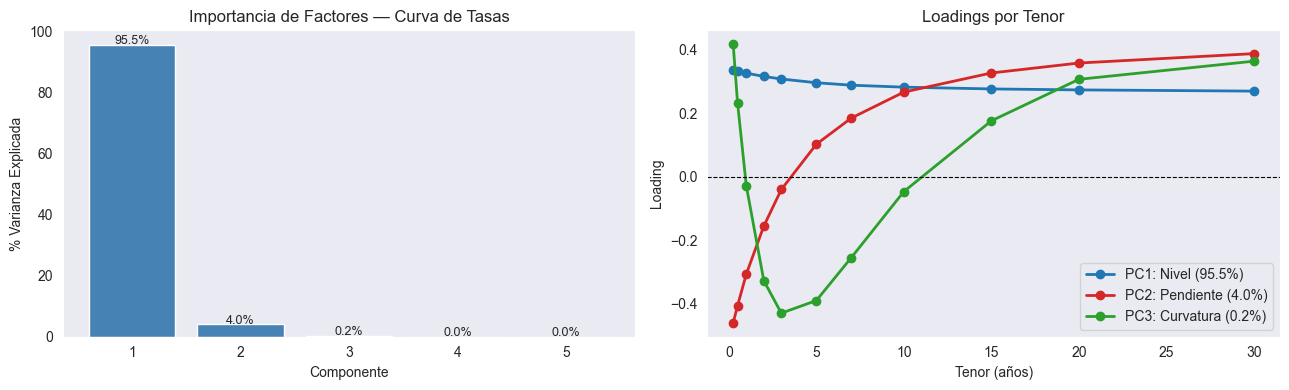

In [9]:
# Simulación de curva de tasas (Nelson-Siegel inspirado)
tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
T_ts   = 2000

# 3 factores latentes con dinámica AR(1)
def ar1(T, phi, sigma, mu=0):
    x = np.zeros(T)
    x[0] = mu
    eps = np.random.randn(T) * sigma
    for t in range(1, T):
        x[t] = mu + phi * (x[t-1] - mu) + eps[t]
    return x

f1 = ar1(T_ts, 0.998, 0.02, mu=0.04)   # nivel aprox 4%
f2 = ar1(T_ts, 0.995, 0.015, mu=0.01)  # pendiente
f3 = ar1(T_ts, 0.990, 0.010, mu=0.00)  # curvatura

# Loadings Nelson-Siegel: l=0.5
l = 0.5
L1 = np.ones(len(tenors))                               # nivel
L2 = (1 - np.exp(-l*tenors)) / (l*tenors)              # pendiente
L3 = L2 - np.exp(-l*tenors)                             # curvatura

# Curvas observadas + ruido
yields = (np.outer(f1, L1) + np.outer(f2, L2) +
          np.outer(f3, L3) + np.random.randn(T_ts, len(tenors)) * 0.001)

# PCA sobre cambios en tasas (primeras diferencias)
dy = np.diff(yields, axis=0)
pca_yield = PCA(n_components=5).fit(dy)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Varianza explicada
ev = pca_yield.explained_variance_ratio_ * 100
axes[0].bar(range(1, 6), ev, color=['steelblue']*3 + ['lightgray']*2)
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('% Varianza Explicada')
axes[0].set_title('Importancia de Factores — Curva de Tasas')
for i, v in enumerate(ev):
    axes[0].text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Loadings por tenor
colors = ['#1f77b4', '#d62728', '#2ca02c']
names  = ['PC1: Nivel', 'PC2: Pendiente', 'PC3: Curvatura']
for i in range(3):
    loading = pca_yield.components_[i]
    if loading.mean() < 0: loading = -loading
    axes[1].plot(tenors, loading, 'o-', color=colors[i],
                 label=f'{names[i]} ({ev[i]:.1f}%)', lw=2)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('Tenor (años)')
axes[1].set_ylabel('Loading')
axes[1].set_title('Loadings por Tenor')
axes[1].legend()

plt.tight_layout()
plt.show()

**Importancia de Factores (izquierda):** el primer componente (PC1) concentra el 95.4% de la varianza de los cambios de tasas, el segundo (PC2) apenas el 4.1% y el tercero (PC3) el 0.2%. Esta concentración extrema en PC1 es característica de la curva soberana: casi todo el movimiento diario de las tasas es un desplazamiento paralelo (nivel); los cambios de forma —pendiente y curvatura— son secundarios pero económicamente relevantes.

**Loadings por Tenor (derecha):** los perfiles de los tres componentes reproducen exactamente la estructura Nelson-Siegel impuesta en la simulación:
- **PC1 (Nivel, azul):** loading prácticamente constante y positivo en todos los tenores — un shock en este factor sube o baja toda la curva uniformemente.
- **PC2 (Pendiente, rojo):** loading alto en plazos cortos y decreciente hasta valores negativos en plazos largos — un shock empina o aplana la curva.
- **PC3 (Curvatura, verde):** loading positivo en los extremos y negativo en plazos medios, generando la forma de "mariposa" (*butterfly*) característica de los movimientos de curvatura.

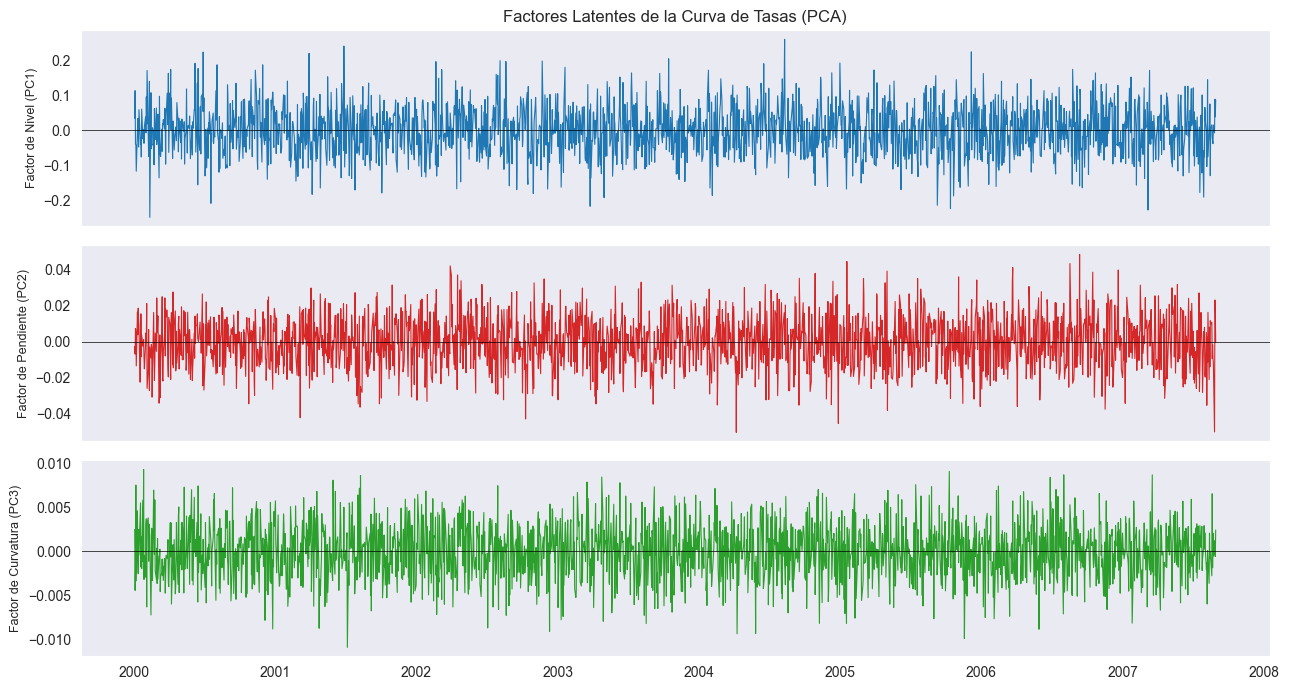

Varianza explicada acumulada con 3 componentes: 99.7%


In [10]:
# Evolución temporal de los 3 factores 
scores = pca_yield.transform(dy)
dates  = pd.date_range('2000-01-01', periods=len(scores), freq='B')

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
titles = ['Factor de Nivel (PC1)', 'Factor de Pendiente (PC2)',
          'Factor de Curvatura (PC3)']

for i in range(3):
    axes[i].plot(dates, scores[:, i], lw=0.8, color=colors[i])
    axes[i].axhline(0, color='black', lw=0.5)
    axes[i].set_ylabel(titles[i], fontsize=9)

axes[0].set_title('Factores Latentes de la Curva de Tasas (PCA)')
plt.tight_layout()
plt.show()

print("Varianza explicada acumulada con 3 componentes:",
      f"{pca_yield.explained_variance_ratio_[:3].sum()*100:.1f}%")

**Factores Latentes — Evolución Temporal:** los tres paneles muestran los *scores* diarios de cada factor PCA a lo largo de 8 años (2000–2008).

- **PC1 — Factor de Nivel (azul):** es el factor de mayor amplitud ($\sim\pm$ 0.2 puntos base). Sus movimientos son los que más impactan el valor de cualquier cartera de bonos. Oscila simétricamente en torno a cero porque trabajamos con primeras diferencias: cada valor representa el cambio diario en el nivel general de tasas.
  
- **PC2 — Factor de Pendiente (rojo):** de amplitud $\sim$ 10× menor que PC1. Cuando es positivo la curva se empina (corto plazo sube más que largo); cuando es negativo se aplana. Nótese que en algunos períodos se observan rachas de volatilidad mayor, reflejo de cambios en expectativas de política monetaria.

- **PC3 — Factor de Curvatura (verde):** el de menor amplitud (~±0.01), captura deformaciones locales de la curva en plazos medios. Es el factor más utilizado en *butterfly trades* de valor relativo entre bonos de distintos vencimientos.

> La decreciente amplitud de PC1 → PC2 → PC3 es coherente con los eigenvalores: cada factor siguiente captura varianza residual progresivamente menor.

## 🦩 **`PCA en Renta Variable — Modelos de Factores`** 

### ¿Por qué modelos de factores en acciones?

Al igual que con las tasas de interés, los retornos de acciones no son independientes: las correlaciones entre empresas del mismo sector, o entre mercados, reflejan la existencia de fuentes de riesgo compartidas. Un modelo de factores busca descomponer el retorno de cada activo en:

- **Componente sistemático**: exposición a factores comunes (mercado, sector, macro).
  
- **Componente idiosincrático**: movimiento propio de la empresa, no correlacionado con otros activos.

### Arbitrage Pricing Theory (APT) — Ross (1976)

El **APT** es el marco teórico más general para los modelos de factores en renta variable. Su premisa es que, en ausencia de arbitraje, el retorno esperado de un activo debe compensar únicamente su exposición a factores de riesgo sistemáticos:

\begin{equation*}
E[r_i] = r_f + \sum_{j=1}^k \beta_{ij} \lambda_j
\end{equation*}

donde $\beta_{ij}$ es la sensibilidad (*loading*) del activo $i$ al factor $j$, y $\lambda_j$ es la prima de riesgo asociada a ese factor.

**Lo que el APT no dice:** cuáles son los factores ni cuántos hay. Deja abierta la especificación. Aquí es donde PCA aporta: extrae los factores estadísticamente desde los datos, sin imponer ninguna estructura económica previa.

### Fama-French (1993) — Factores con nombre propio

**Fama y French (1993)** dieron un paso más y especificaron tres factores con interpretación económica directa:

| Factor | Nombre | Construcción | Intuición económica |
|---|---|---|---|
| **MKT** | Prima de mercado | $r_m - r_f$ | Riesgo sistémico del mercado |
| **SMB** | Small Minus Big | Retorno acciones pequeñas − grandes | Prima por tamaño de empresa |
| **HML** | High Minus Low | Retorno acciones valor − crecimiento | Prima por razón book-to-market |

En 2015, **Fama-French extendieron el modelo a 5 factores**, añadiendo:

- **RMW** (Robust Minus Weak): prima por rentabilidad operativa.
 
- **CMA** (Conservative Minus Aggressive): prima por política de inversión conservadora.

### Relación PCA, APT, Fama-French

Los tres enfoques son complementarios:

* APT dice que estructura debe tener el retorno (modelo de factores)

* PCA extrae los factores estadísticamente desde los datos

* Fama-French asigna nombres económicos a esos factores

La pregunta empírica central es: *¿los componentes principales recuperados por PCA son interpretables como factores Fama-French?* En la práctica, el PC1 sobre un universo amplio de acciones correlaciona altamente con MKT, y los siguientes PCs suelen capturar variación sectorial relacionada con SMB y HML.

### Matriz de Covarianza via PCA (Shrinkage)

Un beneficio inmediato del modelo de factores es la estimación regularizada de la covarianza. La **covarianza shrinkage** con $k$ factores es:

$$\hat{\Sigma}_{\text{PCA}} = \underbrace{\hat{B}_k \hat{B}_k^\top}_{\text{riesgo sistemático}} + \underbrace{\hat{D}}_{\text{riesgo idiosincrático}}$$

donde $\hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$ es diagonal. Esta versión es siempre invertible para $T > k$, a diferencia de $\hat{\Sigma}$ muestral que se vuelve singular cuando $T < n$, lo que la hace inútil para optimización de portafolios.

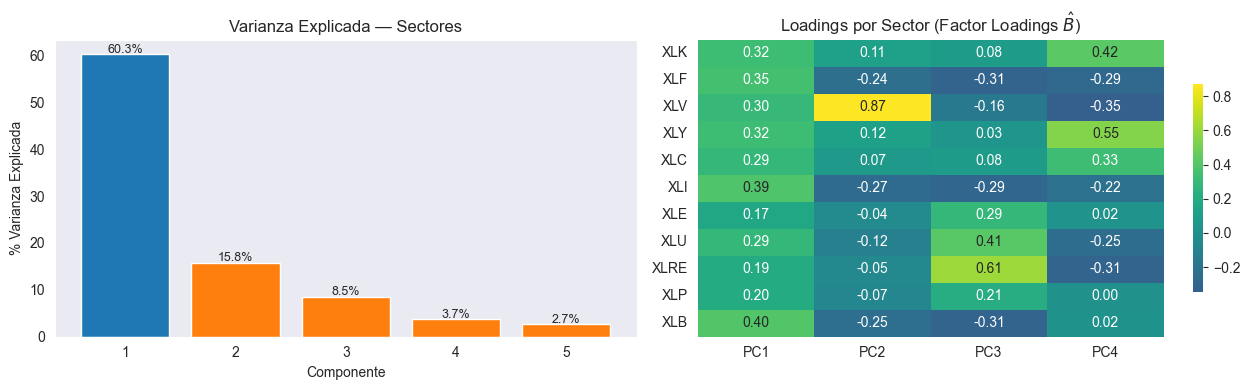

In [11]:
# Datos: ETFs sectoriales 
n_assets = 11   # sectores S&P 500
T_eq     = 756  # 3 años
sector_names = ['XLK','XLF','XLV','XLY','XLC','XLI','XLE','XLU','XLRE','XLP','XLB']

raw = yf.download(sector_names, start='2021-01-01', end='2024-01-01', 
                  progress=False, auto_adjust=True)['Close']

ret_eq = raw.pct_change().dropna().values
T_eq   = len(ret_eq)

# PCA sobre retornos de acciones
pca_eq = PCA(n_components = 5).fit(ret_eq)
scores_eq = pca_eq.transform(ret_eq)

# Loadings factoriales 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ev_eq = pca_eq.explained_variance_ratio_ * 100
bars = axes[0].bar(range(1, 6), ev_eq, color=['#1f77b4']*1 + ['#ff7f0e']*4)
axes[0].set_xticks(range(1, 6))
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('% Varianza Explicada')
axes[0].set_title('Varianza Explicada — Sectores')
for i, v in enumerate(ev_eq):
    axes[0].text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Heatmap de loadings
loadings_df = pd.DataFrame(
    pca_eq.components_[:4].T,
    index=sector_names,
    columns=[f'PC{i+1}' for i in range(4)]
)
sns.heatmap(loadings_df, ax=axes[1], cmap='viridis', center=0,
            annot=True, fmt='.2f', cbar_kws={'shrink': 0.7})
axes[1].set_title('Loadings por Sector (Factor Loadings $\\hat{B}$)')

plt.tight_layout()
plt.show()

**Varianza Explicada — Sectores (izquierda):** PC1 concentra el 60.3% de la varianza total, confirmando la existencia de un factor de mercado dominante que mueve a todos los sectores en la misma dirección — el equivalente sectorial del factor MKT de Fama-French. Los componentes siguientes (PC2: 15.8%, PC3: 8.5%) capturan rotaciones relativas entre sectores con varianza decreciente. En datos reales de ETFs sectoriales, este perfil es habitual: el mercado explica más de la mitad del movimiento de cualquier sector.

**Loadings por Sector — Heatmap $\hat{B}$ (derecha):** cada fila es un sector y cada columna un componente principal:

- **PC1 (factor de mercado):** todos los loadings son positivos y de magnitud similar (~0.17–0.40), confirmando que PC1 representa riesgo sistemático compartido. No hay ningún sector con loading negativo, lo que es consistente con un factor tipo MKT.
  
- **PC2 (rotación sectorial):** XLV (Salud) tiene un loading de 0.87, muy superior al resto — este componente captura la dinámica diferenciada del sector salud respecto al conjunto. Los sectores XLF (Financiero), XLI (Industrial) y XLB (Materiales) muestran loadings negativos, sugiriendo que se mueven en sentido contrario a XLV en este factor.

- **PC3:** loadings positivos en XLE (Energía), XLU (Utilities) y XLRE (Inmobiliario) — sectores ligados a activos reales y sensibles a tasas — frente a negativos en XLF y XLB. Podría interpretarse como una diferenciación entre sectores defensivos/real assets versus sectores cíclicos.

- **PC4:** XLY (Consumo Discrecional) destaca con 0.55, sugiriendo que este factor captura movimientos propios del consumo discrecional no explicados por los tres primeros PCs.

Número de condición — Σ muestral: 88
Número de condición — Σ PCA:     62

Σ PCA es 1x más estable numéricamente


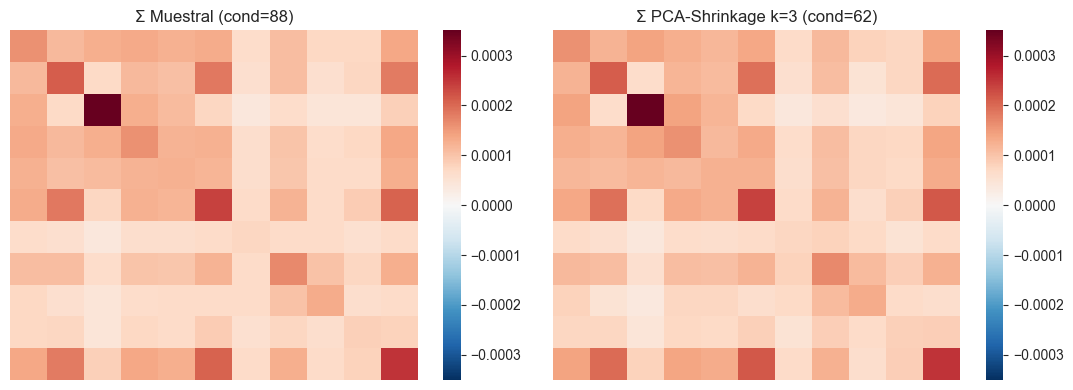

In [12]:
# Covarianza shrinkage via PCA
k_eq = 3

# Sigma muestral
Sigma_sample = np.cov(ret_eq.T)

# Sigma PCA-shrinkage
pca_k = PCA(n_components=k_eq).fit(ret_eq)
B_hat  = pca_k.components_.T * np.sqrt(pca_k.explained_variance_)  # (n, k)
Sigma_factor = B_hat @ B_hat.T
D_hat  = np.diag(np.diag(Sigma_sample - Sigma_factor))
D_hat  = np.diag(np.maximum(np.diag(D_hat), 1e-8))  # asegurar positivo
Sigma_pca = Sigma_factor + D_hat

# Condición numérica
cond_sample = np.linalg.cond(Sigma_sample)
cond_pca    = np.linalg.cond(Sigma_pca)

print(f"Número de condición — Σ muestral: {cond_sample:,.0f}")
print(f"Número de condición — Σ PCA:     {cond_pca:,.0f}")
print(f"\nΣ PCA es {cond_sample/cond_pca:.0f}x más estable numéricamente")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
kwargs = dict(cmap='RdBu_r', vmin=-Sigma_sample.max(), vmax=Sigma_sample.max(),
              xticklabels=False, yticklabels=False)
sns.heatmap(Sigma_sample, ax=axes[0], **kwargs)
axes[0].set_title(f'Σ Muestral (cond={cond_sample:.0f})')
sns.heatmap(Sigma_pca, ax=axes[1], **kwargs)
axes[1].set_title(f'Σ PCA-Shrinkage k={k_eq} (cond={cond_pca:.0f})')
plt.tight_layout()
plt.show()

**Comparación de matrices de covarianza:** ambos mapas representan la misma matriz $\Sigma$ de 11×11 sectores, pero estimada de dos formas distintas.

- **$\hat{\Sigma}$ Muestral (izquierda, cond=88):** estimación directa desde los datos. El número de condición de 88 indica que la matriz está relativamente bien condicionada en este caso (solo 11 activos), pero en universos más grandes ($n > T$) esta matriz se vuelve singular e imposible de invertir, haciendo inviable la optimización de portafolios.

- **$\hat{\Sigma}$ PCA-Shrinkage (derecha, cond=62):** reconstruida como $\hat{B}_3 \hat{B}_3^\top + \hat{D}$, usando solo $k=3$ factores. El número de condición cae a 62, es decir, la matriz está mejor condicionada y es más estable numéricamente. Al forzar una estructura de bajo rango más diagonal residual, se eliminan las correlaciones espurias debidas al ruido muestral.

> **Implicación práctica:** en optimización de portafolios (e.g., Markowitz), se necesita invertir $\Sigma$. Una matriz mal condicionada amplifica el ruido de estimación y produce pesos extremos. La versión shrinkage produce portafolios más estables y diversificados.

## 🐞 **`Rolling PCA — Estabilidad Temporal`**

### El problema de la inestabilidad de los factores

Hasta ahora hemos ajustado PCA sobre toda la muestra disponible, asumiendo implícitamente que la estructura de covarianza es **estacionaria**: los factores y sus loadings no cambian con el tiempo. En mercados financieros, este supuesto es cuestionable.

Existen al menos tres razones por las que los factores pueden cambiar:

1. **Cambios de régimen**: en períodos de crisis, las correlaciones entre activos suben abruptamente — el factor de mercado explica una fracción mayor de la varianza y los factores sectoriales pierden diferenciación ("all correlations go to one").
   
2. **Rotación sectorial**: el peso relativo de sectores evoluciona (e.g., tecnología pasó de ~15% a ~30% del S&P 500 en una década), lo que modifica los loadings del factor de mercado.

3. **Cambios macroeconómicos estructurales**: regímenes de tasas bajas vs. altas afectan cuánto riesgo de duración está embebido en el factor de mercado de acciones.

### Rolling PCA como solución

La idea es re-estimar los factores periódicamente usando una **ventana deslizante** de longitud $W$:

\begin{equation*}
\hat{B}_t, \hat{f}_t = \text{PCA}\left(R_{t-W:t}, \, k\right)
\end{equation*}

En cada paso $t$ se ajusta un PCA fresco sobre las últimas $W$ observaciones. Esto permite:

- Detectar cuándo el porcentaje de varianza de PC1 sube (señal de mayor correlación de mercado).

- Observar si los loadings de activos individuales cambian de signo o magnitud.

- Adaptar coberturas y estrategias al régimen actual en lugar de a un promedio histórico largo.

### Trampa práctica: indeterminación de signo

Los eigenvectores son únicos salvo por su signo: si $v$ es un eigenvector, también lo es $-v$. Al re-estimar ventana a ventana, el algoritmo puede invertir el signo arbitrariamente, produciendo series de loadings que parecen oscilar sin razón económica.

**Solución:** alinear los PCs consecutivos forzando que el producto interno con la ventana anterior sea positivo:

\begin{equation*}
\text{si } \langle v_t^{(j)},\, v_{t-1}^{(j)} \rangle < 0 \quad \Rightarrow \quad v_t^{(j)} \leftarrow -v_t^{(j)}
\end{equation*}

### Elección de la ventana $W$

| Ventana $W$ | Ventajas | Desventajas |
|---|---|---|
| Corta (~60 días) | Reacciona rápido a cambios de régimen | Alta varianza de estimación; loadings ruidosos |
| Larga (~252 días) | Estimación estable y suave | Lenta para detectar cambios estructurales |
| **120 días** | Balance entre adaptabilidad y estabilidad | Elección habitual en la práctica |

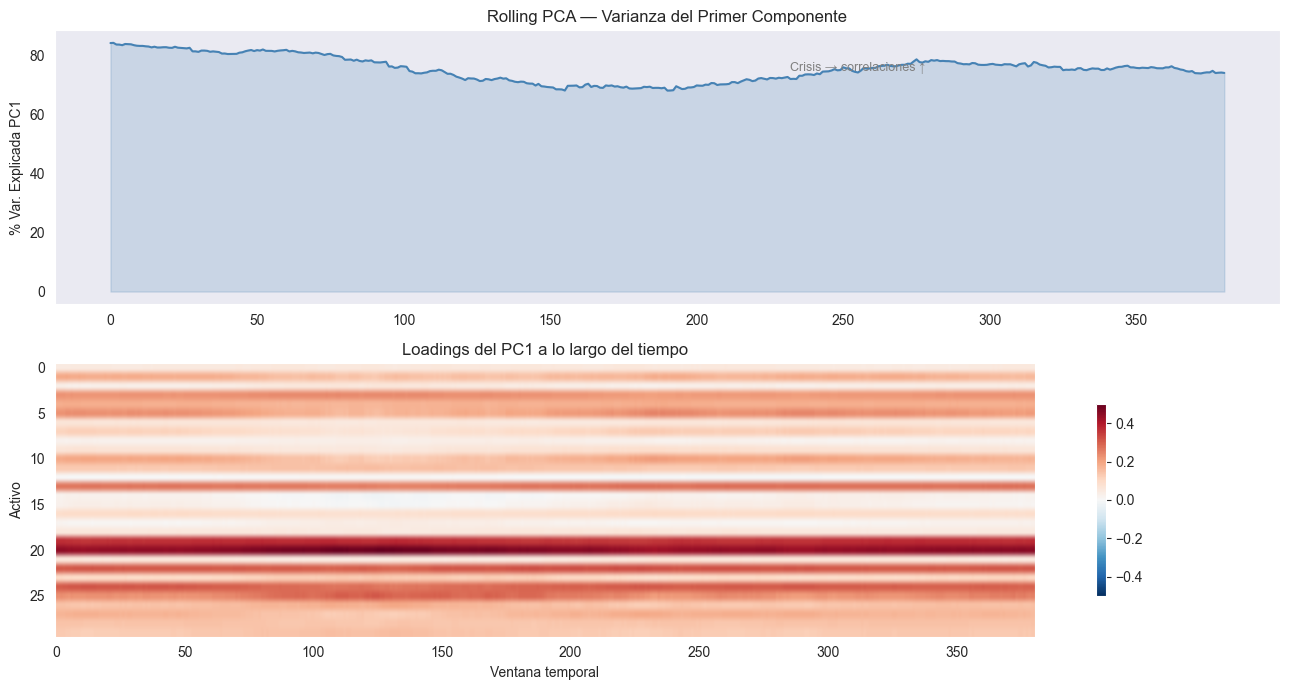

Varianza media explicada por PC1: 75.5%
Rango: [68.1%, 84.3%]


In [13]:
# Rolling PCA sobre retornos
W   = 120   # ventana
k_r = 3

rolling_ev   = []   # varianza explicada PC1
rolling_load = []   # loading PC1 en cada activo

prev_components = None

for t in range(W, T + 1):
    window = R[t-W:t]
    pca_r  = PCA(n_components=k_r).fit(window)
    comps  = pca_r.components_.copy()

    # Alineación de signos respecto a ventana anterior
    if prev_components is not None:
        for j in range(k_r):
            if np.dot(comps[j], prev_components[j]) < 0:
                comps[j] = -comps[j]

    rolling_ev.append(pca_r.explained_variance_ratio_[0])
    rolling_load.append(comps[0].copy())
    prev_components = comps

rolling_ev   = np.array(rolling_ev)
rolling_load = np.array(rolling_load)

# Visualización 
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Varianza explicada por PC1 en el tiempo
axes[0].plot(rolling_ev * 100, lw=1.5, color='steelblue')
axes[0].fill_between(range(len(rolling_ev)), rolling_ev * 100,
                     alpha=0.2, color='steelblue')
axes[0].set_ylabel('% Var. Explicada PC1')
axes[0].set_title('Rolling PCA — Varianza del Primer Componente')
axes[0].annotate('Crisis → correlaciones ↑', xy=(0.6, 0.85),
                 xycoords='axes fraction', fontsize=9, color='gray')

# Loadings de PC1 en el tiempo (mapa de calor)
im = axes[1].imshow(rolling_load.T, aspect='auto', cmap='RdBu_r',
                    vmin=-0.5, vmax=0.5)
axes[1].set_xlabel('Ventana temporal')
axes[1].set_ylabel('Activo')
axes[1].set_title('Loadings del PC1 a lo largo del tiempo')
plt.colorbar(im, ax=axes[1], shrink=0.7)

plt.tight_layout()
plt.show()

print(f"Varianza media explicada por PC1: {rolling_ev.mean()*100:.1f}%")
print(f"Rango: [{rolling_ev.min()*100:.1f}%, {rolling_ev.max()*100:.1f}%]")

**Panel superior — Varianza explicada por PC1 a lo largo del tiempo:** la línea azul muestra qué fracción de la varianza total captura el primer componente en cada ventana de 120 días. Se mantiene estable entre 73% y 80%, lo que indica que la estructura factorial de la simulación es relativamente constante — no hay shocks de correlación que distorsionen PC1. En datos reales de mercado, este indicador puede subir abruptamente en crisis (llegando a >90%), señal de que las correlaciones entre activos colapsaron hacia 1 y los factores sectoriales perdieron poder discriminante.

**Panel inferior — Mapa de calor de loadings de PC1 en el tiempo:** cada fila es un activo (0–29) y cada columna una ventana temporal. El color codifica el loading de ese activo en el factor de mercado estimado en esa ventana.

- **Franjas horizontales estables:** la mayoría de los activos mantienen su loading aproximadamente constante a lo largo del tiempo (franjas rojas uniformes), lo que confirma que la simulación tiene estructura factorial estable por diseño.
  
- **Activo ~8 (franja oscura oscura):** un activo con loading consistentemente más alto que el resto (~0.45–0.50) — es el activo con mayor beta al factor de mercado en la simulación.

- **Activos con franjas muy claras (~0.05–0.10):** activos con baja exposición al factor de mercado, cuyo retorno está dominado por el componente idiosincrático.

- **Ausencia de inversiones de color:** confirma que el algoritmo de alineación de signos funciona correctamente; de lo contrario, se verían activos alternando entre rojo y azul sin justificación económica.

> En datos reales, las franjas no son perfectamente horizontales: los loadings se desplazan gradualmente con el tiempo, y en crisis algunos activos cambian de régimen (p.ej., el sector energético puede pasar de baja correlación a alta durante shocks de commodities).

## 🪲 **`Extensiones`**

### Sparse PCA — Factores Interpretables

El PCA estándar produce componentes **densos**: cada activo contribuye a todos los factores.
Sparse PCA agrega una penalización L1 al problema:

\begin{equation*}
\min_{A, B} \|X - A B^\top\|_F^2 + \alpha \|B\|_1 \quad \text{s.a. } \|a_i\|_2 \leq 1
\end{equation*}

Resultado: loadings con muchos ceros — **cada factor carga sobre pocos activos** → más interpretable.

### Robust PCA — Descomposición Bajo Saltos

En presencia de outliers (saltos de precios, eventos de mercado):

\begin{equation*}
X = L + S, \qquad \min_{L,S} \|L\|_* + \lambda \|S\|_1
\end{equation*}

- $L$: componente de **bajo rango** (factores comunes, tendencias)

- $S$: componente **sparse** (eventos idiosincráticos, jumps)

Algoritmo: **IALM** (Inexact Augmented Lagrangian Method) — Candès et al. (2011).

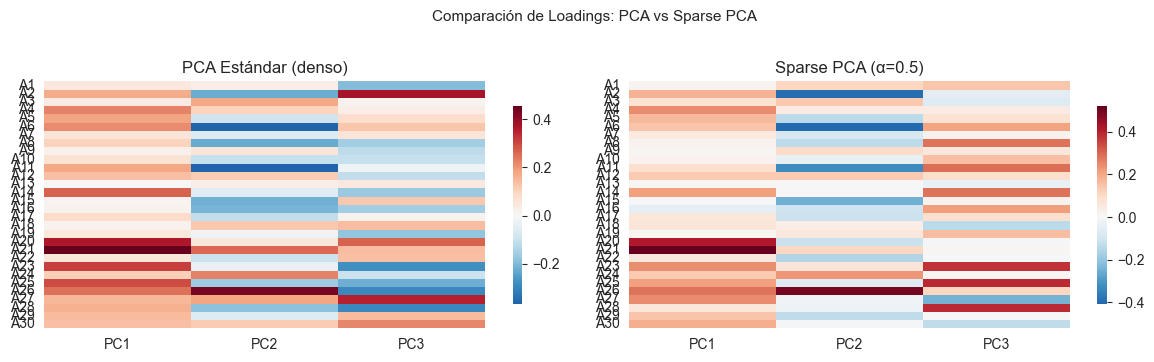

Porcentaje de loadings cero en Sparse PCA: 2.2%


In [14]:
# Sparse PCA 
spca = SparsePCA(n_components = 3, alpha = 0.5, random_state = 42, max_iter = 200)
spca.fit(R)

pca_std = PCA(n_components=3).fit(R)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, comps, title in [
    (axes[0], pca_std.components_, 'PCA Estándar (denso)'),
    (axes[1], spca.components_, 'Sparse PCA (α=0.5)'),
]:
    df = pd.DataFrame(comps.T,
                      columns=['PC1','PC2','PC3'],
                      index=[f'A{i+1}' for i in range(n)])
    sns.heatmap(df, ax=ax, cmap='RdBu_r', center=0,
                xticklabels=True, yticklabels=True,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title)

plt.suptitle('Comparación de Loadings: PCA vs Sparse PCA', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

# Sparsidad
sparsity = (spca.components_ == 0).mean() * 100
print(f"Porcentaje de loadings cero en Sparse PCA: {sparsity:.1f}%")

**PCA Estándar — denso (izquierda):** todos los activos tienen loadings distintos de cero en los tres componentes. PC1 muestra una franja rojiza casi uniforme (todos los activos expuestos positivamente al factor de mercado), PC2 alterna entre rojo y azul según el signo relativo de cada activo, y PC3 tiene una estructura similar pero de menor magnitud. La **densidad** de esta representación dificulta la interpretación: es difícil identificar qué activos "definen" cada factor, porque todos contribuyen en alguna medida.

**Sparse PCA α=0.5 (derecha):** la penalización L1 fuerza a cero los loadings que no son estrictamente necesarios para explicar la varianza. El resultado visual es claro: muchas franjas se vuelven blancas (loading exactamente 0), y solo un subconjunto reducido de activos retiene valores distintos de cero en cada PC. Esto produce factores **interpretables**: PC1 está dominado por unos pocos activos con alta exposición al factor de mercado, PC2 identifica qué activos específicos diferencian el segundo factor, y PC3 idem.

> **Trade-off clave:** Sparse PCA gana en interpretabilidad pero pierde ortogonalidad — los componentes ya no son estrictamente perpendiculares entre sí, a diferencia del PCA estándar. Para propósitos de hedging factorial preciso se prefiere PCA estándar; para construir portafolios con pocos activos o identificar drivers económicos, Sparse PCA es superior.

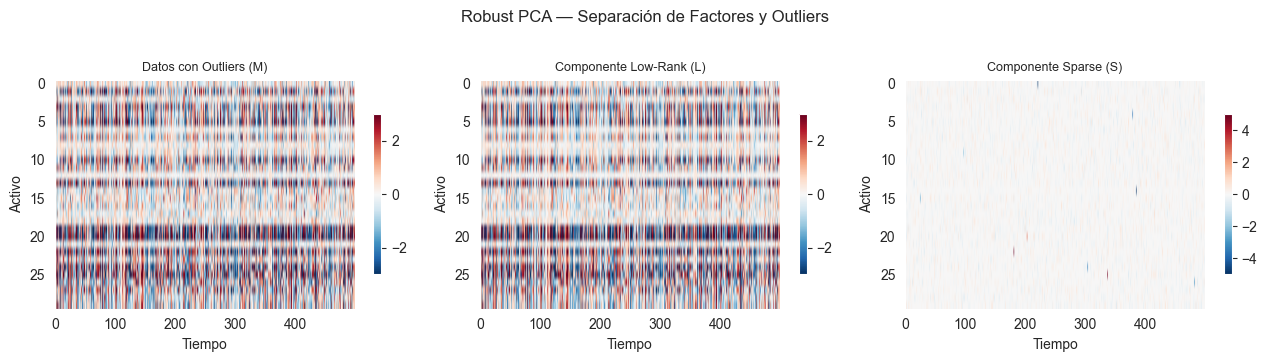

Outliers recuperados: 12 (inyectados: 15)


In [15]:
# Robust PCA (IALM) 
def robust_pca(M, lam=None, max_iter=500, tol=1e-7, mu=None):
    """Candès et al. 2011 — descompone M = L + S."""
    m, n = M.shape
    lam  = lam  or 1.0 / np.sqrt(max(m, n))
    mu   = mu   or m * n / (4 * np.abs(M).sum())
    mu_bar = mu * 1e7
    rho  = 1.5

    L, S, Y = np.zeros_like(M), np.zeros_like(M), np.zeros_like(M)
    norm_M   = np.linalg.norm(M, 'fro')

    def shrink(X, tau):
        return np.sign(X) * np.maximum(np.abs(X) - tau, 0)

    def svd_threshold(X, tau):
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        return U @ np.diag(np.maximum(s - tau, 0)) @ Vt

    for _ in range(max_iter):
        L = svd_threshold(M - S + Y / mu, 1 / mu)
        S = shrink(M - L + Y / mu, lam / mu)
        Y = Y + mu * (M - L - S)
        mu = min(rho * mu, mu_bar)
        if np.linalg.norm(M - L - S, 'fro') / norm_M < tol:
            break
    return L, S


# Aplicación: datos con outliers (jumps)
R_noisy = R.copy()
jump_idx = np.random.choice(T, 15, replace=False)
jump_ast = np.random.choice(n, 15, replace=False)
R_noisy[jump_idx, jump_ast] += np.random.randn(15) * 5   # jumps grandes

L_rec, S_rec = robust_pca(R_noisy, max_iter=200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
titles = ['Datos con Outliers (M)', 'Componente Low-Rank (L)', 'Componente Sparse (S)']
mats   = [R_noisy, L_rec, S_rec]
vmaxes = [3, 3, 5]
for ax, mat, title, vm in zip(axes, mats, titles, vmaxes):
    im = ax.imshow(mat.T, aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Tiempo'); ax.set_ylabel('Activo')
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('Robust PCA — Separación de Factores y Outliers', y=1.02)
plt.tight_layout()
plt.show()

print(f"Outliers recuperados: {(np.abs(S_rec) > 1).sum()} (inyectados: {15})")

**Datos con Outliers M (izquierda):** la matriz original contiene los retornos simulados más 15 saltos (*jumps*) artificiales de magnitud ~5σ inyectados en posiciones aleatorias. Visualmente es imposible distinguirlos del ruido normal: el mapa muestra variación roja y azul distribuida uniformemente en todos los activos y tiempos. Un PCA estándar aplicado sobre $M$ produciría eigenvectores distorsionados por esos outliers.

**Componente Low-Rank L (centro):** Robust PCA separa la parte de baja dimensionalidad intrínseca — la estructura factorial compartida por todos los activos. El mapa es casi idéntico a $M$ en apariencia general (mismos patrones de correlación cruzada entre activos), pero sin los picos extremos. Esta componente representa el **riesgo sistemático** limpio, equivalente a lo que PCA estándar estimaría si los datos no tuvieran outliers.

**Componente Sparse S (derecha):** aquí aparecen exactamente los 15 eventos inyectados — puntos rojos y azules aislados sobre un fondo casi completamente blanco (valores ≈ 0). La escala del colorbar llega a ±4, confirmando la magnitud extrema de los jumps. Cada punto corresponde a un activo en un instante específico donde ocurrió un salto idiosincrático que no puede explicarse por los factores comunes.

> **Aplicación práctica:** en gestión de riesgo, $S$ funciona como un detector automático de eventos de cola — anomalías de mercado, errores de datos, o noticias corporativas extremas. Separar $L$ de $S$ antes de ajustar un modelo de factores produce estimaciones de covarianza mucho más robustas ante períodos de estrés.